<a href="https://colab.research.google.com/github/cibi-ruba-arasu/Machine_Learning_from_Scratch/blob/main/04_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as tts
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [39]:
!wget -q https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv

In [40]:
data = pd.read_csv("pokemon.csv")
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [41]:
data.shape

(800, 13)

In [42]:
data.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

let us just consider the pokemons with type Grass and Electric

In [43]:
data1 = data.query("`Type 1`.isin(('Electric','Grass'))")
data1

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
30,25,Pikachu,Electric,NaN,320,35,55,40,50,50,90,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,672,Skiddo,Grass,NaN,350,66,65,48,62,57,52,6,False
741,673,Gogoat,Grass,NaN,531,123,100,62,97,81,68,6,False
764,694,Helioptile,Electric,Normal,289,44,38,33,61,43,70,6,False
765,695,Heliolisk,Electric,Normal,481,62,55,52,109,94,109,6,False


based on the following stats("HP","Attack","Defense","Speed"), we will predict the type of Pokemon

In [44]:
stats = data1[["HP","Attack","Defense","Speed"]]
X = stats
X

,HP,Attack,Defense,Speed
0,45,49,49,45
1,60,62,63,60
2,80,82,83,80
3,80,100,123,80
30,35,55,40,90
...,...,...,...,...
740,66,65,48,52
741,123,100,62,68
764,44,38,33,70
765,62,55,52,109


In [45]:
y = (data1['Type 1'] == "Electric") #electric =1, grass =0
y

,Type 1
0,False
1,False
2,False
3,False
30,True
...,...
740,False
741,False
764,True
765,True


In [46]:
d_tree = DecisionTreeClassifier(max_depth=1) # max_depth attribute defines how many features to compare(ask yes or no) to predict, here we ask 1 yes/no question. the trick is to find hte feature that answers the best to find the cut-off

In [47]:
d_tree.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[3] <= 85.5\ngini = 0.474\nsamples = 114\nvalue = [70, 44]'),
 Text(0.25, 0.25, 'gini = 0.354\nsamples = 74\nvalue = [57, 17]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.439\nsamples = 40\nvalue = [13, 27]'),
 Text(0.625, 0.5, '  False')]

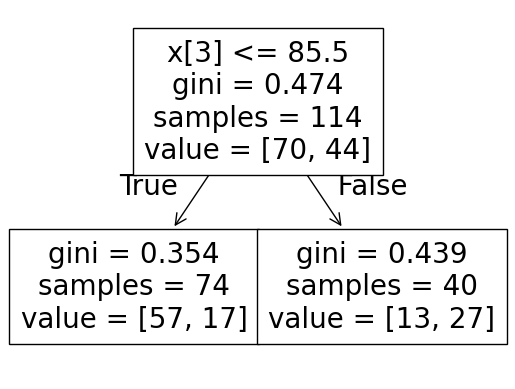

In [48]:
plot_tree(d_tree)

In [49]:
accuracy_score(y, d_tree.predict(X)) # accuracy for a decision tree with maximum depth =1

0.7368421052631579

x[3], here means the feature Speed. if it is <=85.8, it is Grass , else it is Electric

In [50]:
test_sample = [[35, 55, 40, 90]] #(this is features of Pikachu) speed is 90, so it is electric
pred = d_tree.predict(test_sample)
print(pred)

[ True]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [51]:
#lets try max_depth = 2; i.e., ask 2 questions before finalisig the output
d_tree2 = DecisionTreeClassifier(max_depth=2)

In [52]:
d_tree2.fit(X,y)

DecisionTreeClassifier(max_depth=2)

[Text(0.5, 0.8333333333333334, 'x[3] <= 85.5\ngini = 0.474\nsamples = 114\nvalue = [70, 44]'),
 Text(0.25, 0.5, 'x[2] <= 34.5\ngini = 0.354\nsamples = 74\nvalue = [57, 17]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.306\nsamples = 69\nvalue = [56, 13]'),
 Text(0.75, 0.5, 'x[0] <= 90.5\ngini = 0.439\nsamples = 40\nvalue = [13, 27]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.394\nsamples = 37\nvalue = [10, 27]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

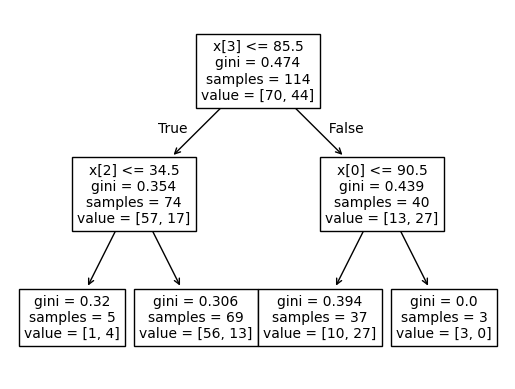

In [53]:
plot_tree(d_tree2)

In [54]:
accuracy_score(y, d_tree2.predict(X)) # accuracy for a decision tree with maximum depth =2

0.7894736842105263

The Accuracy would keep increasing cuz we increase max_depth, but at some point the model begind to "memorize" the data(overfitting) making it unpredictable for a new data.

So, we make train test split.

In [55]:
x_graph = []
y_graph = []
acc = 0
ind = 0
depth = 1
for i in range(0, 20):
  tree = DecisionTreeClassifier(max_depth = depth).fit(X,y)
  acc = accuracy_score(y, tree.predict(X))
  x_graph.append(depth)
  y_graph.append(acc)
  ind+=1
  depth+=1

print(x_graph)
print(y_graph)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
[0.7368421052631579, 0.7894736842105263, 0.8070175438596491, 0.8070175438596491, 0.8596491228070176, 0.8947368421052632, 0.9122807017543859, 0.9210526315789473, 0.9385964912280702, 0.9385964912280702, 0.956140350877193, 0.9649122807017544, 0.9736842105263158, 0.9912280701754386, 0.9912280701754386, 1.0, 1.0, 1.0, 1.0, 1.0]


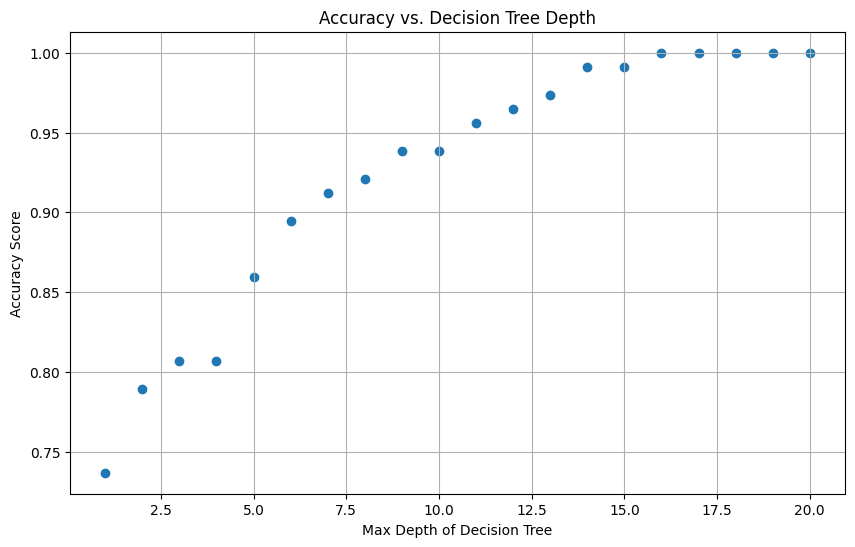

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x_graph, y_graph)
plt.title('Accuracy vs. Decision Tree Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

This is why we use Train test split to find the perfect max_deth for the model

In [57]:
x1_graph = []
training_acc = []
testing_acc =[]

depth1 = 1

X_train,X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=2)

for i in range(0,20):
  tree2 = DecisionTreeClassifier(max_depth=depth1).fit(X_train, y_train)

  acc1 = accuracy_score(y_train, tree2.predict(X_train))
  acc2 = accuracy_score(y_test, tree2.predict(X_test))

  x1_graph.append(depth1)
  training_acc.append(acc1)
  testing_acc.append(acc2)
  depth1+=1

print("X(max_depth):",x1_graph)
print("Training Accuracy(y1):",training_acc)
print("Testing Accuracy(y2)",testing_acc)

X(max_depth): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Training Accuracy(y1): [0.7472527472527473, 0.8131868131868132, 0.8571428571428571, 0.8901098901098901, 0.945054945054945, 0.945054945054945, 0.978021978021978, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Testing Accuracy(y2) [0.6956521739130435, 0.6086956521739131, 0.6086956521739131, 0.6086956521739131, 0.5217391304347826, 0.4782608695652174, 0.5652173913043478, 0.5652173913043478, 0.5652173913043478, 0.4782608695652174, 0.5217391304347826, 0.5652173913043478, 0.4782608695652174, 0.6086956521739131, 0.5652173913043478, 0.5652173913043478, 0.5652173913043478, 0.4782608695652174, 0.5217391304347826, 0.5652173913043478]


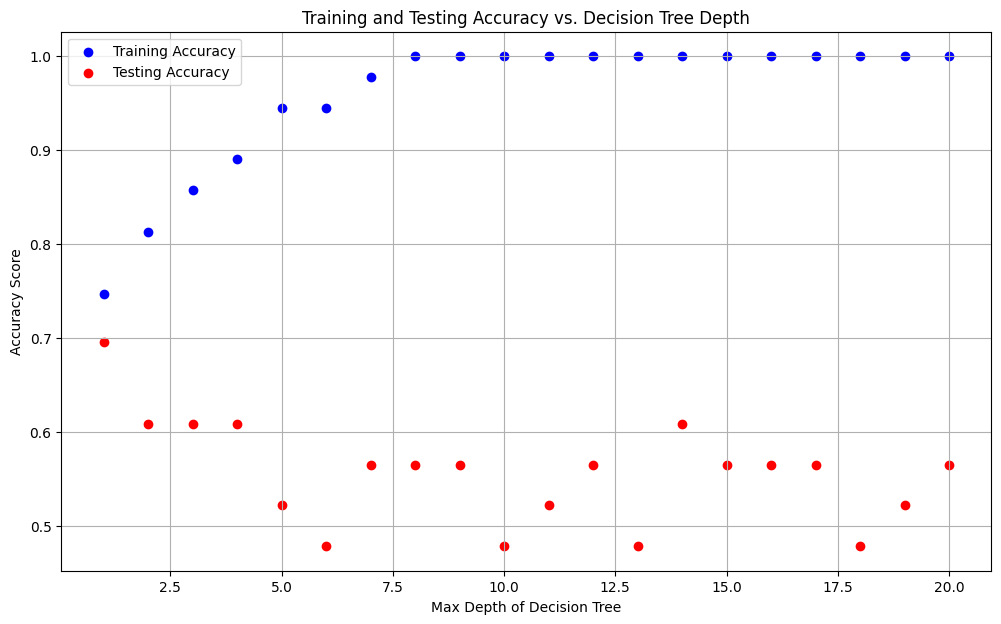

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.scatter(x1_graph, training_acc, color='blue', label='Training Accuracy')
plt.scatter(x1_graph, testing_acc, color='red', label='Testing Accuracy')
plt.title('Training and Testing Accuracy vs. Decision Tree Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.show()

# **Finalizing the weights**

1) simply assgn with the maximum testing accuracy
2) Use Grid Search CV(Cross-Validation) => hyper parameter tuning https://www.youtube.com/watch?v=csae_xWc1kw

In [59]:
best_test_acc = max(testing_acc)

for i in range(0, 20):
  if best_test_acc == testing_acc[i]:
    print("Max Depth : ", i+1)
    #break (breaking here would not return the correct depth. try using break in this line)
  else:
    continue

Max Depth :  1


In [60]:

# 1. Define the parameters you want to test in a dictionary
# This tells it to test max_depths from 1 to 20
param_grid = {
    'max_depth': range(1, 21)
}

# 2. Create the base model
tree = DecisionTreeClassifier(random_state=42)

# 3. Set up the Grid Search
# cv=5 means it tests each depth 5 times on different slices of the data for better reliability
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring='accuracy')

# 4. Fit it to your training data (This does all the looping for you!)
grid_search.fit(X_train, y_train)

# 5. Extract the best depth and best score
print(f"The optimal max_depth found by GridSearchCV is: {grid_search.best_params_['max_depth']}")
print(f"The best cross-validated training accuracy was: {grid_search.best_score_:.4f}")

# You can also instantly grab the perfectly tuned model like this:
best_tree_model = grid_search.best_estimator_

The optimal max_depth found by GridSearchCV is: 2
The best cross-validated training accuracy was: 0.7251


In [61]:
Acc = accuracy_score(y_test, best_tree_model.predict(X_test))
Acc

0.6086956521739131

# **From scratch Understanding how features are selected and how gini values help find best Condition**

Row,Weather (Cat), Age (Num),Income ($k) (Num),Purchased (Target)

1,-------Sunny,------22,--------30,----------------No

2,-------Sunny,------28,--------80,---------------Yes

3,-------Rainy,------35,--------40,---------------No

4,-------Rainy,------45,--------90,---------------Yes

5,-------Sunny,------50,---------85,---------------Yes



In [62]:
dataset_X = np.array([[1,22,30],[1,28,80],[2,35,40],[2,45,90],[1,50,85]])
dataset_y = np.array([[0],[1],[0],[1],[1]])

In [63]:
gini_values_for_each_feature=[]

In [64]:
#FINDING GINI INDEX FOR WEATHER FEATURE

#Sunny - > No  = 1/3 [(no. of values that are both sunny and No) /(no. of sunny values)]
#Sunny - > Yes = 2/3
#Rainy - > No = 1/2
#Rainy - > Yes = 1/2

gini_sunny = 1 - (np.square(1/3) + np.square(2/3))

gini_rainy = 1- (np.square(1/2)+np.square(1/2))
print("gini index for Sunny Samples : ", gini_sunny)
print("gini index for Rainy Samples :", gini_rainy)

#Sunny = 3/5
#Rainy = 2/5

gini_weather =  (((3/5)*gini_sunny) +((2/5)*gini_rainy))
print("Gini Value for both weather : ", gini_weather)
gini_values_for_each_feature.append(gini_weather)

gini index for Sunny Samples :  0.4444444444444444
gini index for Rainy Samples : 0.5
Gini Value for both weather :  0.4666666666666667


In [65]:
#FINDING GINI INDEX FOR AGE FEATURE

#find sorted age values
sorted_age = np.sort([22,28,35,45,50])

#now, we find the candidate's midpoints (eg: (22+28)/2 = 25)

age_midpoint=[]
for i in range(0, len(sorted_age)-1):
  age_midpoint.append((sorted_age[i]+sorted_age[i+1])/2)

#Threshold 1 where age <= (midpoint of arr[0] and arr[1])
#Left Gini for threshold 1 (condition satisfied) ===> 22 = No (0 yes, 1 no)
#Right Gini for threshold 1 (condition not satisfied) ===> 28 = Yes, 35= No, 45= yes, 50 = yes (3 yes,1 no)

#Gini(Left) = 1 - [(0/1)^2 + (1/1)^2] = 0.0
#Gini(Right) = 1 - [(3/4)^2 + (1/4)^2] = 0.3750

#Weighted_Gini for Threshold 1 = (1/5) * 0.0 + (4/5) * 0.3750 = 0.3000

#Likewise find weighted Gini for all thresholds. the threshold with the lowest value would be our "best condition"

unique_outputs = []
unique_output_count = 0

for ii in range(0, len(dataset_y)):
  xx = dataset_y[ii]
  if xx in unique_outputs:
    continue
  else:
    unique_outputs.append(xx)
    unique_output_count+=1

print("arr", unique_outputs, "count:", unique_output_count)

age_array = []

for k in range(0 , len(dataset_X)):
  age_array.append(dataset_X[k][1])

weighted_gini_age = []

for jj in range(0, len(age_midpoint)):
  current_threshold = age_midpoint[jj]
  print("threshold ",jj+1," :",current_threshold)
  left_gini_yes = 0
  left_gini_no = 0
  left_sat_count = 0
  right_gini_yes = 0
  right_gini_no = 0
  right_sat_count = 0
  for kk in range(0, len(age_array)):
    if(age_array[kk] <= current_threshold):
      if(dataset_y[kk][0] == 1):
        left_gini_yes+=1
      else:
        left_gini_no += 1
      left_sat_count += 1
    else:
      if(dataset_y[kk][0] == 1):
        right_gini_yes += 1
      else:
        right_gini_no += 1
      right_sat_count +=1

  left_gini_weight = 1 - ((left_gini_yes/left_sat_count)**2 + (left_gini_no/left_sat_count)**2)
  right_gini_weight = 1 - ((right_gini_yes/right_sat_count)**2 + (right_gini_no/right_sat_count)**2)
  print("left gini weight for threshold ", jj+1," = ",left_gini_weight)
  print("right gini weight for threshold ", jj+1," = ",right_gini_weight)

  weighted_gini = (left_sat_count/len(age_array)*left_gini_weight) + (right_sat_count/len(age_array)*right_gini_weight)

  print("Weighted Gini for Threshold", jj+1,"=", weighted_gini)
  weighted_gini_age.append(weighted_gini)

print(weighted_gini_age)

print("best condition is where gini value is : ",min(weighted_gini_age))
gini_values_for_each_feature.append(min(weighted_gini_age))

arr [array([0]), array([1])] count: 2
threshold  1  : 25.0
left gini weight for threshold  1  =  0.0
right gini weight for threshold  1  =  0.375
Weighted Gini for Threshold 1 = 0.30000000000000004
threshold  2  : 31.5
left gini weight for threshold  2  =  0.5
right gini weight for threshold  2  =  0.4444444444444444
Weighted Gini for Threshold 2 = 0.4666666666666667
threshold  3  : 40.0
left gini weight for threshold  3  =  0.4444444444444444
right gini weight for threshold  3  =  0.0
Weighted Gini for Threshold 3 = 0.26666666666666666
threshold  4  : 47.5
left gini weight for threshold  4  =  0.5
right gini weight for threshold  4  =  0.0
Weighted Gini for Threshold 4 = 0.4
[0.30000000000000004, 0.4666666666666667, 0.26666666666666666, 0.4]
best condition is where gini value is :  0.26666666666666666


In [66]:
#Similarly we find the gini value for the income dataset

#Income = [30, 80, 40, 90]
#Income_midpoints = [35.0, 60.0, 82.5, 87.5]
#Income <= 35.0: Weighted Gini = 0.3000
#Income <= 60.0: Weighted Gini = 0.0000
#Income <= 82.5: Weighted Gini = 0.2667
#Income <= 87.5: Weighted Gini = 0.4000

#Weighted_gini_values_of_income = 0.0000

gini_values_for_each_feature.append(0.0000)

In [67]:
gini_values_for_each_feature #choose the feature with the lowest gini value as your root node

[np.float64(0.4666666666666667), 0.26666666666666666, 0.0]

In [68]:
#here, we would have to choose income as our root node where the condition is income <=60

From the Root Node, Based on the condition split Left and Right Chunks

In [69]:
r_chunk = []
l_chunk = []

for g in range(0, len(dataset_X)):
  if(dataset_X[g][2] <=60):
    r_chunk.append(g)
  else:
    l_chunk.append(g)

print("Right Chunk(Condition = T)")

for h in range(0, len(r_chunk)):
  print(dataset_X[r_chunk[h]])
  print("where Y is :", dataset_y[r_chunk[h]])

print("Left Chunk(Condition = F)")
for h in range(0, len(l_chunk)):
  print(dataset_X[l_chunk[h]])
  print("Where Y is :", dataset_y[l_chunk[h]])

Right Chunk(Condition = T)
[ 1 22 30]
where Y is : [0]
[ 2 35 40]
where Y is : [0]
Left Chunk(Condition = F)
[ 1 28 80]
Where Y is : [1]
[ 2 45 90]
Where Y is : [1]
[ 1 50 85]
Where Y is : [1]


The outputs on Both Left Chunk and The Right Chunk is pure. So, we can simply stop here.